In [5]:
pip install WordCloud

  Obtaining dependency information for WordCloud from https://files.pythonhosted.org/packages/b1/6a/47d0d8c5ca74400750797ae8fd13f200204294e008e1235e51814e732b09/wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata
  Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp312-cp312-win_amd64.whl (307 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud 

# Set display parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load cleaned dataset
df = pd.read_csv('cleaned_books.csv')

print("=== Task 1: Scraping Statistics ===")
print(f"Total Scraped Records: {len(df)}")
print(f"Duplicate UPCs: {df['upc'].duplicated().sum()}")
print("\nMissing Values:\n", df.isnull().sum())
print("="*40)

=== Task 1: Scraping Statistics ===
Total Scraped Records: 100
Duplicate UPCs: 0

Missing Values:
 title                     0
category                  0
price                     0
rating                    0
stock_count               0
description               0
upc                       0
number_of_reviews         0
product_url               0
description_word_count    0
price_band                0
value_score               0
dtype: int64


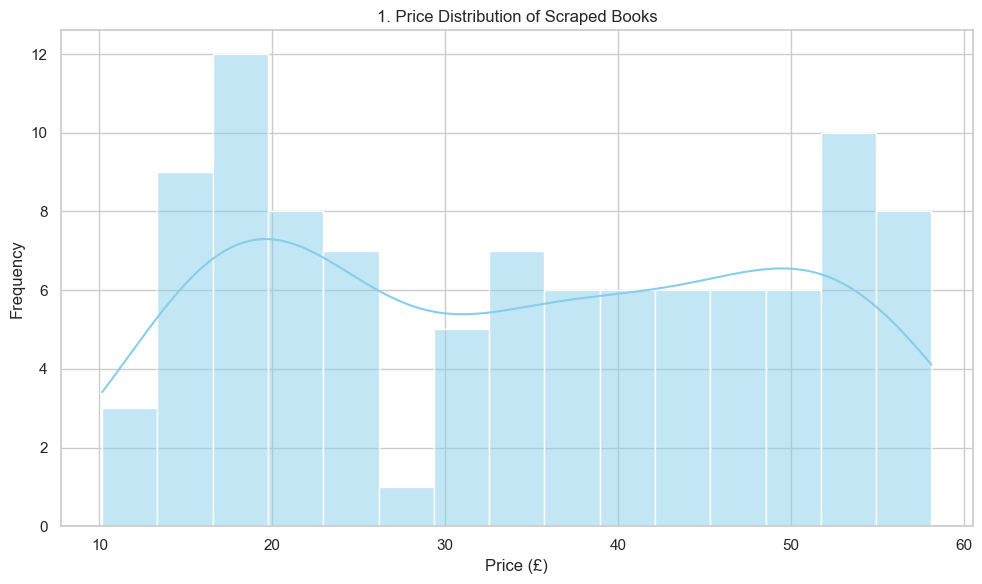

In [8]:
plt.figure()
sns.histplot(df['price'], kde=True, color='skyblue', bins=15)
plt.title('1. Price Distribution of Scraped Books')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_10456\2598738438.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


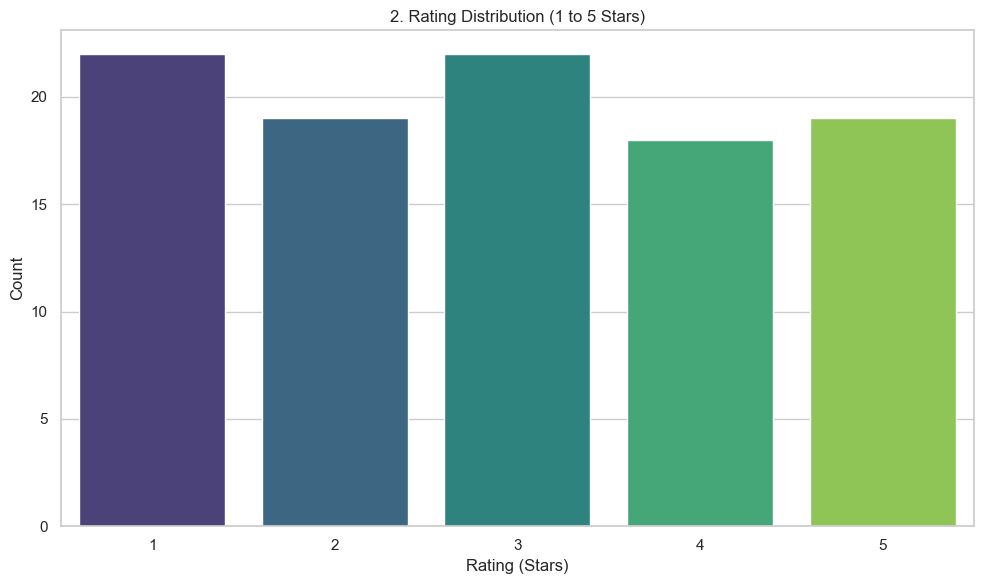

In [9]:
plt.figure()
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('2. Rating Distribution (1 to 5 Stars)')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('rating_distribution.png')
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_10456\825722961.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='category', data=avg_price_cat, palette='magma')


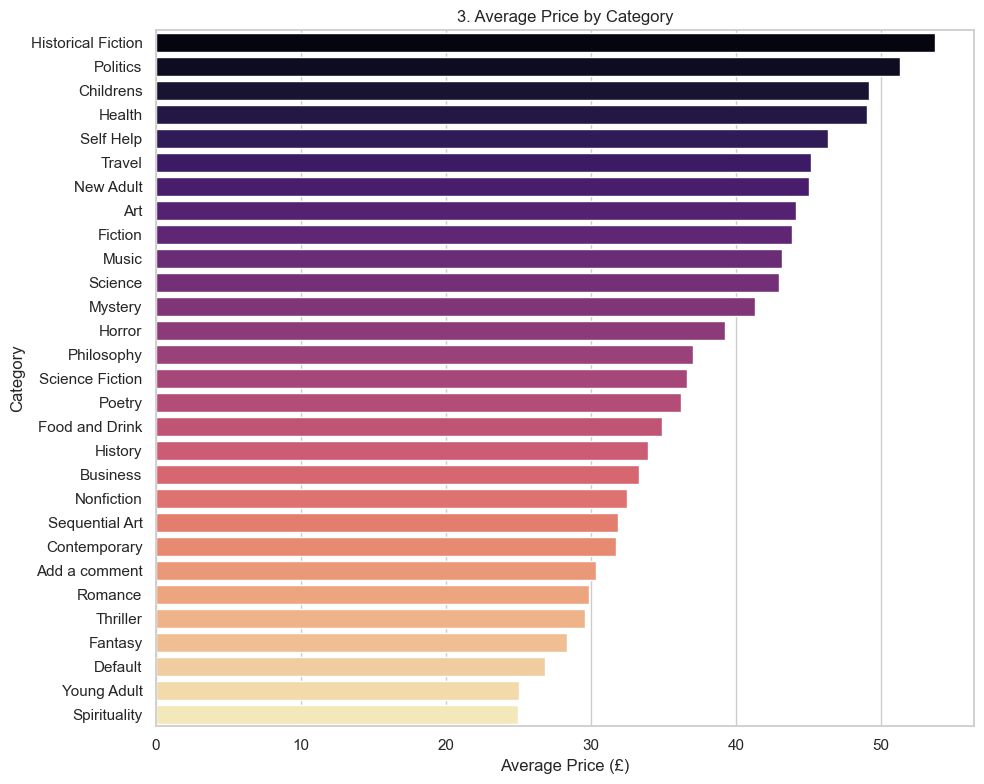

In [10]:
plt.figure(figsize=(10, 8))
avg_price_cat = df.groupby('category')['price'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='price', y='category', data=avg_price_cat, palette='magma')
plt.title('3. Average Price by Category')
plt.xlabel('Average Price (£)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('avg_price_by_category.png')
plt.show()

C:\Users\dhruv\AppData\Local\Temp\ipykernel_10456\3008666658.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='price', data=df, palette='Set2')


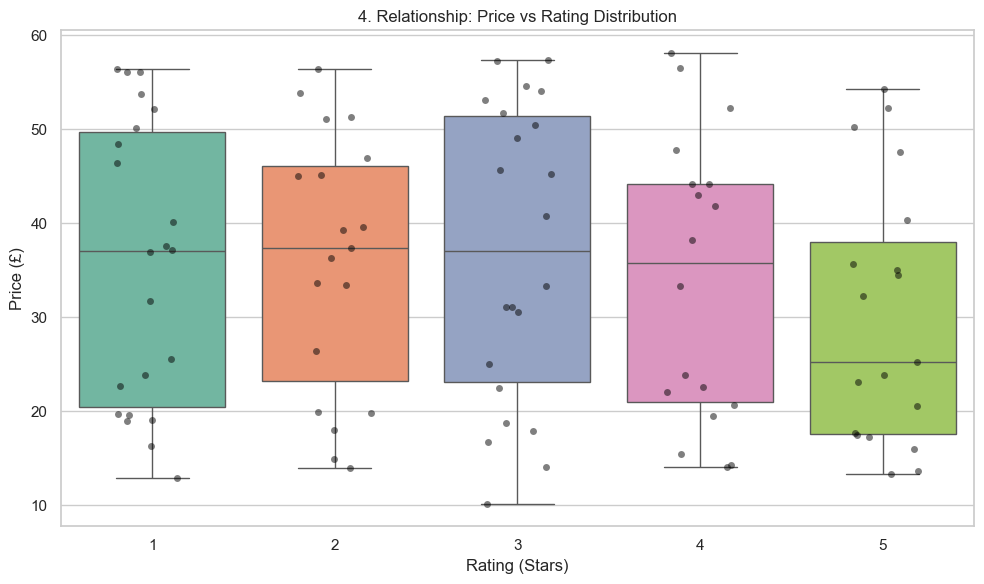

In [11]:
plt.figure()
sns.boxplot(x='rating', y='price', data=df, palette='Set2')
sns.stripplot(x='rating', y='price', data=df, color='black', alpha=0.5, jitter=0.2)
plt.title('4. Relationship: Price vs Rating Distribution')
plt.xlabel('Rating (Stars)')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.savefig('price_vs_rating.png')
plt.show()

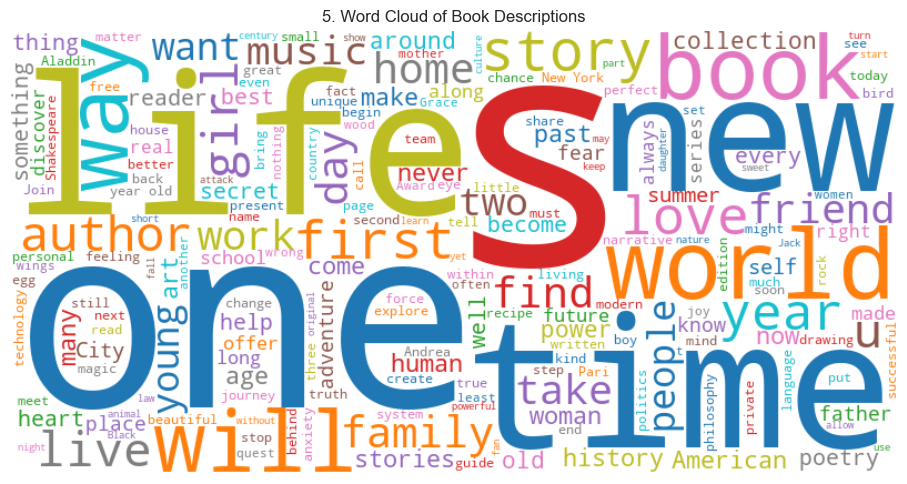

In [12]:
text = " ".join(df['description'].dropna().tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('5. Word Cloud of Book Descriptions')
plt.tight_layout()
plt.savefig('wordcloud.png')
plt.show()

In [13]:
print("="*50)
print("          TASK 4: INSIGHTS & REPORT")
print("="*50)

# 1. Price Stats
print("\n1. PRICE & RATING SUMMARY:")
print(f"   - Average Price: £{df['price'].mean():.2f}")
print(f"   - Price Range  : £{df['price'].min():.2f} to £{df['price'].max():.2f}")
print(f"   - Price vs Rating Correlation: {df['price'].corr(df['rating']):.4f}")

# 2. Top Categories
print("\n2. TOP 3 MOST REPRESENTED CATEGORIES:")
top_cats = df['category'].value_counts().head(3)
for cat, count in top_cats.items():
    print(f"   - {cat}: {count} books")

# 3. Category Pricing Extremes
cat_means = df.groupby('category')['price'].mean()
print("\n3. CATEGORY PRICING EXTREMES:")
print(f"   - Most Expensive Category : {cat_means.idxmax()} (£{cat_means.max():.2f} avg)")
print(f"   - Most Affordable Category: {cat_means.idxmin()} (£{cat_means.min():.2f} avg)")

# 4. Top Value Books
print("\n4. TOP 3 BEST VALUE BOOKS (Rating / Price * 100):")
top_value = df.sort_values(by='value_score', ascending=False)[['title', 'price', 'rating', 'value_score']].head(3)
for idx, row in top_value.iterrows():
    print(f"   - '{row['title']}' | {row['rating']} Stars | £{row['price']} | Score: {row['value_score']}")

print("="*50)

          TASK 4: INSIGHTS & REPORT

1. PRICE & RATING SUMMARY:
   - Average Price: £34.56
   - Price Range  : £10.16 to £58.11
   - Price vs Rating Correlation: -0.1217

2. TOP 3 MOST REPRESENTED CATEGORIES:
   - Sequential Art: 14 books
   - Nonfiction: 12 books
   - Default: 9 books

3. CATEGORY PRICING EXTREMES:
   - Most Expensive Category : Historical Fiction (£53.74 avg)
   - Most Affordable Category: Spirituality (£24.95 avg)

4. TOP 3 BEST VALUE BOOKS (Rating / Price * 100):
   - 'Princess Between Worlds (Wide-Awake Princess #5)' | 5 Stars | £13.34 | Score: 37.48
   - 'Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Princess Jellyfish 2-in-1 Omnibus #1)' | 5 Stars | £13.61 | Score: 36.74
   - 'Sophie's World' | 5 Stars | £15.94 | Score: 31.37
